## 1. Load in Data

In [ ]:
# enviorment: base
import os
import copy
import scanpy as sc
import pandas as pd
from scipy.io import mmread
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, random_split
import spapros as sp
import squidpy as sq

# os.chdir('./code')

adata00 = sc.read_h5ad('./data/Yao_sc/WMB-10Xv2-CTXsp-log2.h5ad')
adata01 = copy.deepcopy(adata00) 
# Basic filtering
sc.pp.filter_cells(adata01, min_genes=200)  # Filter out cells with fewer than 200 genes
sc.pp.filter_genes(adata01, min_cells=100)    # Filter out genes detected in fewer than 3 cells
print(f'Number of cells after processing: {adata01.n_obs}')
print(f'Number of genes after processing: {adata01.n_vars}')
# Normalization
sc.pp.normalize_total(adata01, target_sum=1e4)  # Normalize each cell to 10,000 reads
# Calculate mean and variance
gene_means = adata01.X.mean(axis=0).tolist()  # axis=0 calculates the mean across cells for each gene
# Convert to a more readable format (Pandas DataFrame)
gene_stats = pd.DataFrame({
    'Gene': adata01.var_names,
    'Mean': gene_means[0]
})
gene_identifier_1 = adata01.var_names.tolist()

# === get data 2 (MERFISH) ===
MER_cell_metadata   = pd.read_csv("./data/Yao_MERFISH/Zhuang4/cell_metadata.csv")
MER_ccf_coordinates = pd.read_csv("./data/Yao_MERFISH/Zhuang4/ccf_coordinates.csv")
MER_gene            = pd.read_csv("./data/Yao_MERFISH/Zhuang4/gene.csv")
MER_adata = sc.read_h5ad("./data/Yao_MERFISH/Zhuang4/Zhuang-ABCA-4-log2.h5ad")

gene_identifier_2 = MER_gene['gene_identifier']

/Users/hlu/Library/r-miniconda-arm64/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


Number of cells after processing: 44310
Number of genes after processing: 18873


## 2. Preprocess

In [ ]:
# ==== Find common genes ====
set_1 = set(gene_identifier_1)
set_2 = set(gene_identifier_2)

# Find the common genes
common_genes = set_1.intersection(set_2)

# Convert the result back to a list if needed
common_genes_list = list(common_genes)

# Print some information about the results
print(f"Number of genes in data 1: {len(gene_identifier_1)}")
print(f"Number of genes in data 2: {len(gene_identifier_2)}")
print(f"Number of common genes: {len(common_genes)}")

# == filter data 1 scRNA by common genes

common_genes_set = set(common_genes_list)

# Create a boolean mask for the genes to keep
genes_to_keep = [gene in common_genes_set for gene in adata01.var_names]

# Subset the AnnData object
adata01_common = adata01[:, genes_to_keep].copy()

# Print information about the new dataset
print(f"Original number of genes: {adata01.n_vars}")
print(f"Number of common genes: {adata01_common.n_vars}")
print(f"Number of cells in common genes dataset: {adata01_common.n_obs}")

# # Verify that all genes in the new object are in the common genes list
# all_common = all(gene in common_genes_set for gene in adata01_common.var_names)
# print(f"All genes in new object are common genes: {all_common}")



Number of genes in data 1: 18873
Number of genes in data 2: 1122
Number of common genes: 1014
Original number of genes: 18873
Number of common genes: 1014
Number of cells in common genes dataset: 44310
Data saved to 'MER_adata_common.csv'


In [ ]:
# all_gene_symbols = adata01_common.var['gene_symbol']
# all_gene_symbols_df = all_gene_symbols.reset_index()
# all_gene_symbols_df.columns = ['gene_identifier', 'gene_symbol']

# save_path = './gene_panels/all_gene_symbols.csv'
# all_gene_symbols_df.to_csv(save_path, index=False)

file_path = './gene_panels/all_gene_symbols.csv'

all_gene_symbols = pd.read_csv(file_path)
all_gene_symbols

,gene_identifier,gene_symbol
0,ENSMUSG00000025905,Oprk1
1,ENSMUSG00000033774,Npbwr1
2,ENSMUSG00000033740,St18
3,ENSMUSG00000042501,Cpa6
4,ENSMUSG00000025938,Slco5a1
...,...,...
1009,ENSMUSG00000025268,Maged2
1010,ENSMUSG00000046550,Spin2c
1011,ENSMUSG00000031298,Adgrg2
1012,ENSMUSG00000031364,Grpr


## 3. Method

Epoch [1/20], Train Loss: 0.4236, Test Loss: 0.3497, L1 Penalty (Train Only): 0.088847
Epoch [2/20], Train Loss: 0.3381, Test Loss: 0.3195, L1 Penalty (Train Only): 0.075895
Epoch [3/20], Train Loss: 0.3173, Test Loss: 0.3051, L1 Penalty (Train Only): 0.063053
Epoch [4/20], Train Loss: 0.3054, Test Loss: 0.2946, L1 Penalty (Train Only): 0.050465
Epoch [5/20], Train Loss: 0.2964, Test Loss: 0.2875, L1 Penalty (Train Only): 0.038216
Epoch [6/20], Train Loss: 0.2896, Test Loss: 0.2809, L1 Penalty (Train Only): 0.026456
Epoch [7/20], Train Loss: 0.2846, Test Loss: 0.2768, L1 Penalty (Train Only): 0.015647
Epoch [8/20], Train Loss: 0.2811, Test Loss: 0.2743, L1 Penalty (Train Only): 0.009771
Epoch [9/20], Train Loss: 0.2781, Test Loss: 0.2710, L1 Penalty (Train Only): 0.008202
Epoch [10/20], Train Loss: 0.2751, Test Loss: 0.2690, L1 Penalty (Train Only): 0.007196
Epoch [11/20], Train Loss: 0.2728, Test Loss: 0.2668, L1 Penalty (Train Only): 0.006439
Epoch [12/20], Train Loss: 0.2706, Test L

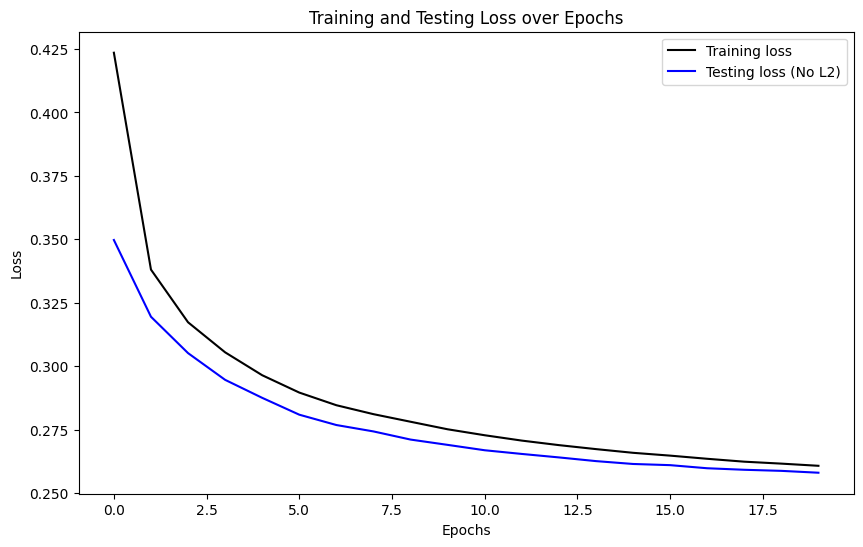

In [3]:
#==== AE method code + L2(Common Genes of Data 1 and 2)
num_epochs = 20

adata = copy.deepcopy(adata01) 
sc.pp.scale(adata, max_value=10)
 
# Custom Dataset class
class GeneExpressionDataset(Dataset):
    def __init__(self, matrix):
        self.matrix = matrix

    def __len__(self):
        return len(self.matrix)

    def __getitem__(self, idx):
        return self.matrix[idx]

# Prepare the data for training and testing
gene_expression_matrix = torch.tensor(adata01_common.X.toarray() if hasattr(adata01_common.X, "toarray") else adata01_common.X, dtype=torch.float32)
dataset = GeneExpressionDataset(gene_expression_matrix)

# Split the dataset into training and test sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

os.makedirs("./results", exist_ok=True)

# Autoencoder model definition
class FeatureScreeningAutoencoder(nn.Module):
    def __init__(self, input_size, embedding_size, dp=0.2, lk=0.2):
        super(FeatureScreeningAutoencoder, self).__init__()
        
        self.feature_importance = nn.Parameter(torch.ones(input_size))
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(lk, inplace=True),
            nn.Dropout(dp),
            nn.Linear(512, 256),
            nn.LeakyReLU(lk, inplace=True),
            nn.Dropout(dp),
            nn.Linear(256, embedding_size),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(embedding_size, 256),
            nn.LeakyReLU(lk, inplace=True),
            nn.Dropout(dp),
            nn.Linear(256, 512),
            nn.LeakyReLU(lk, inplace=True),
            nn.Linear(512, input_size),
        )
        
    def forward(self, x):
        screened_features = x * self.feature_importance
        encoded = self.encoder(screened_features)
        decoded = self.decoder(encoded)
        return screened_features, encoded, decoded

# Parameters
input_size = adata01_common.n_vars
embedding_size = 200
dp = 0.05
lk = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the autoencoder
autoencoder = FeatureScreeningAutoencoder(input_size, embedding_size, dp, lk).to(device)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

# Training loop
# Define L2 penalty weight for feature importance
# Define L2 penalty weight for feature importance
l_lambda = 1e-4  # Adjust this as needed

# Training loop with L2 penalty on feature importance (only in training)

train_loss_all = []
test_loss_all = []

for epoch in range(num_epochs):
    autoencoder.train()
    train_loss = 0
    
    for data in train_loader:
        genes = data.to(device)
        screened_features, _, outputs = autoencoder(genes)
        
        # Compute reconstruction loss
        loss = criterion(outputs, genes)
        
        # Add L2 penalty only for feature importance weights (only in training)
        # l2_penalty = l_lambda * torch.norm(autoencoder.feature_importance, p=2) ** 2
        l1_penalty = l_lambda * torch.norm(autoencoder.feature_importance, p=1)
        total_loss = loss + l1_penalty  # Only used in training
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * genes.size(0)  # Store only reconstruction loss
    
    train_loss /= len(train_loader.dataset)
    train_loss_all.append(train_loss)
    
    # Evaluate on test data (without L2 penalty)
    autoencoder.eval()
    test_loss = 0
    with torch.no_grad():
        for data in test_loader:
            genes = data.to(device)
            _, _, outputs = autoencoder(genes)
            loss = criterion(outputs, genes)  # No L2 penalty during testing
            test_loss += loss.item() * genes.size(0)
    
    test_loss /= len(test_loader.dataset)
    test_loss_all.append(test_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, L1 Penalty (Train Only): {l1_penalty.item():.6f}')

# Save the trained model
torch.save(autoencoder.state_dict(), './results/autoencoder_common_genes.pth')

print("Final training loss: ", train_loss_all[-1])
print("Final testing loss: ", test_loss_all[-1])

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_loss_all, color="black", label="Training loss")
plt.plot(range(num_epochs), test_loss_all, color="blue", label="Testing loss (No L2)")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss over Epochs')
plt.legend()
plt.savefig('./results/loss_curve_common_genes.png')
plt.show()


## 4. After Training

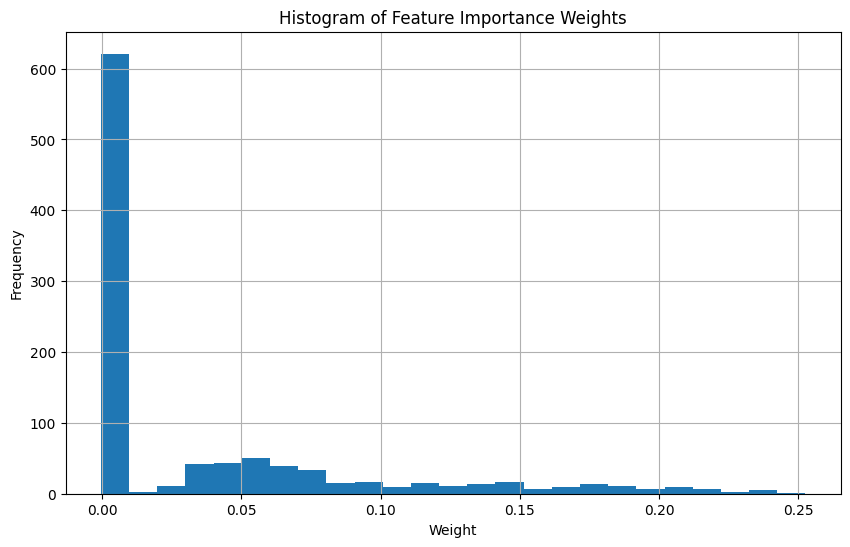

In [4]:
# === After training
feature_importances = autoencoder.feature_importance.data

# Assuming feature_importances contains the data from autoencoder.feature_importance.data
feature_importances = autoencoder.feature_importance.data.cpu().numpy()  # Ensure it's on CPU and convert to NumPy

# Plot the histogram
plt.figure(figsize=(10, 6))  # Set the figure size
plt.hist(feature_importances, bins=25, alpha=1)  # Adjust bins as necessary
plt.title('Histogram of Feature Importance Weights')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [5]:
# Step 1: Filter data 2 (MER_adata) for common genes
# Assuming we have the list of common genes from earlier steps

# Create a boolean mask for the genes to keep in data 2
genes_to_keep_data2 = [gene in set(common_genes_list) for gene in MER_adata.var_names]

# Subset data 2 to include only common genes
MER_adata_common = MER_adata[:, genes_to_keep_data2].copy()

print(f"Number of cells in data 2 (common genes): {MER_adata_common.n_obs}")
print(f"Number of genes in data 2 (common genes): {MER_adata_common.n_vars}")

# Ensure the gene order is the same as in data 1
MER_adata_common = MER_adata_common[:, adata01_common.var_names].copy()

# Step 2: Prepare data 2 for testing
class GeneExpressionDataset(Dataset):
    def __init__(self, matrix):
        self.matrix = matrix

    def __len__(self):
        return len(self.matrix)

    def __getitem__(self, idx):
        return self.matrix[idx]

gene_expression_matrix_data2 = torch.tensor(MER_adata_common.X.toarray() if hasattr(MER_adata_common.X, "toarray") else MER_adata_common.X, dtype=torch.float32)
test_dataset_data2 = GeneExpressionDataset(gene_expression_matrix_data2)
test_loader_data2 = DataLoader(test_dataset_data2, batch_size=256, shuffle=False)

# Step 3: Load the trained autoencoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure this matches the architecture used during training
input_size = adata01_common.n_vars

dp = 0.05
lk = 0.3

autoencoder = FeatureScreeningAutoencoder(input_size, embedding_size, dp, lk).to(device)
autoencoder.load_state_dict(torch.load('./results/autoencoder_common_genes.pth'))
autoencoder.eval()

# Step 4: Evaluate the model on data 2
criterion = nn.MSELoss()
test_loss_data2 = 0

with torch.no_grad():
    for data in test_loader_data2:
        genes = data.to(device)
        _, _, outputs = autoencoder(genes)
        loss = criterion(outputs, genes)
        test_loss_data2 += loss.item() * genes.size(0)

test_loss_data2 /= len(test_loader_data2.dataset)

print(f"Testing Loss (all genes) on Data 2 (MER_adata): {test_loss_data2:.4f}")


Number of cells in data 2 (common genes): 215278
Number of genes in data 2 (common genes): 1014


/var/folders/bb/wz4wt6yj3z16t5r9lfym2qww0000gn/T/ipykernel_16510/3743714450.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('./re

Testing Loss (all genes) on Data 2 (MER_adata): 0.1696


In [6]:
# **************** test Our Method *****************

# Assuming feature_importances is a PyTorch tensor of shape [num_features]
median_val = feature_importances.mean()

# Create a mask for genes to keep (weights in the larger 50% part)
genes_to_keep_mask = feature_importances >= 0.001
print("number of selected genes: ", np.sum(genes_to_keep_mask))


# Assuming test_loader is your DataLoader for the test dataset
# Modify the test dataset to set unselected genes to 0

def filter_genes(data, mask):
    # Use the mask to set unselected genes to 
    if not isinstance(mask, torch.Tensor):
        mask = torch.tensor(mask)
    mask = mask.to(data.device)
    return data * mask

# # Apply the mask to the test data
# filtered_test_loader = DataLoader(
#     [(filter_genes(data[0], genes_to_keep_mask), data[1]) for data in test_dataset],
#     batch_size=256, shuffle=False)


autoencoder.eval()  # Ensure the model is in evaluation mode
test_loss = 0

with torch.no_grad():
    for genes in test_loader_data2:  # Assuming test_loader provides the original gene data
        genes = genes.to(device)
        filtered_genes = filter_genes(genes, genes_to_keep_mask)  # Filter genes for input
        _, _, outputs = autoencoder(filtered_genes)  # Pass filtered genes as input
        loss = criterion(outputs, genes)  # Compare output against full, original genes
        test_loss += loss.item() * genes.size(0)

test_loss /= len(test_loader_data2.dataset)  # Normalize loss by the number of samples

print(f'Test Loss with Our Filtered Genes as Input: {test_loss:.4f}')

number of selected genes:  395
Test Loss with Our Filtered Genes as Input: 0.1696


In [ ]:
# Assuming you have adata or adata01_common that contains the gene_symbol
gene_symbols = adata01_common.var['gene_symbol']

# Applying the mask to get the filtered list of gene symbols
filtered_gene_symbols = gene_symbols[genes_to_keep_mask]

# Convert to a list
filtered_gene_symbols_list = filtered_gene_symbols.tolist()

# Print the list of filtered gene symbols
print(f"Number of genes after masking: {len(filtered_gene_symbols_list)}")
# print(filtered_gene_symbols_list)
filtered_gene_symbols

all_gene_symbols = adata01_common.var['gene_symbol']

Number of genes after masking: 395


gene_identifier
ENSMUSG00000025905      Oprk1
ENSMUSG00000033774     Npbwr1
ENSMUSG00000033740       St18
ENSMUSG00000042501       Cpa6
ENSMUSG00000025938    Slco5a1
                       ...   
ENSMUSG00000025268     Maged2
ENSMUSG00000046550     Spin2c
ENSMUSG00000031298     Adgrg2
ENSMUSG00000031364       Grpr
ENSMUSG00000018589      Glra2
Name: gene_symbol, Length: 1014, dtype: object

In [ ]:
import pandas as pd

# ==== 1. Save feature importances with corresponding gene symbols ====

# Ensure gene_symbols is a pandas Series with the same order as feature_importances
df_importances = pd.DataFrame({
    'gene_symbol': gene_symbols.values,
    'importance': feature_importances
})

df_importances.to_csv('feature_importances.csv', index=False)
print("Saved feature importances to 'feature_importances.csv'")

# ==== 2. Save filtered gene symbols list ====

df_filtered_genes = pd.DataFrame({'filtered_gene_symbol': filtered_gene_symbols_list})
df_filtered_genes.to_csv('filtered_gene_symbols.csv', index=False)
print("Saved filtered gene symbols to 'filtered_gene_symbols.csv'")


Saved feature importances to 'feature_importances.csv'
Saved filtered gene symbols to 'filtered_gene_symbols.csv'
